In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('Các thư viện cần thiết đã được nhập thành công và cấu hình hiển thị đã được đặt.')

Các thư viện cần thiết đã được nhập thành công và cấu hình hiển thị đã được đặt.


# PROBLEM STATEMENT 4: ĐÁNH GIÁ MỨC ĐỘ ỔN ĐỊNH DOANH THU CỦA TỪNG DANH MỤC SẢN PHẨM

### 2. Định nghĩa các bảng dữ liệu

Phần này mô tả các bảng dữ liệu (FACT và DIMENSION) được sử dụng trong phân tích, cùng với các trường dữ liệu quan trọng trong mỗi bảng.

In [4]:
print("\n" + "=" * 100)
print("2. XÁC ĐỊNH BẢNG DỮ LIỆU")
print("=" * 100)

print("""
FACT TABLE:
ORDER_ITEM
- order_id
- product_id
- quantity
- unit_price
- discount_amount

DIMENSION TABLE:
ORDERS
- order_id
- order_date
- order_status

DIMENSION TABLE:
PRODUCT
- product_id
- category
""")


2. XÁC ĐỊNH BẢNG DỮ LIỆU

FACT TABLE:
ORDER_ITEM
- order_id
- product_id
- quantity
- unit_price
- discount_amount

DIMENSION TABLE:
ORDERS
- order_id
- order_date
- order_status

DIMENSION TABLE:
PRODUCT
- product_id
- category



### 3. Định nghĩa các thước đo (Measure)

Phần này xác định các thước đo (Measure) được sử dụng, bao gồm cả các thước đo dữ liệu thô và các thước đo được xây dựng (như Doanh thu).

In [5]:
print("\n" + "=" * 100)
print("3. MEASURE - THƯỚC ĐO")
print("=" * 100)

print("""
Measure dữ liệu thô:
- quantity
- unit_price
- discount_amount

Measure được xây dựng:
Revenue = quantity × unit_price - discount_amount
""")


3. MEASURE - THƯỚC ĐO

Measure dữ liệu thô:
- quantity
- unit_price
- discount_amount

Measure được xây dựng:
Revenue = quantity × unit_price - discount_amount



### 4. Đọc dữ liệu

Đọc các file CSV chứa dữ liệu ORDERS, ORDER_ITEM và PRODUCT vào các DataFrame tương ứng. Sau đó, hiển thị kích thước của mỗi DataFrame để kiểm tra dữ liệu đã được tải thành công.

In [6]:
print("\n" + "=" * 100)
print("4. ĐỌC DỮ LIỆU")
print("=" * 100)

orders_df = pd.read_csv('/content/ORDERS (1).csv')
order_items_df = pd.read_csv('/content/ORDER_ITEM (2).csv')
products_df = pd.read_csv('/content/product (1).csv')

print("\nĐã đọc dữ liệu thành công.")

print(f"ORDERS: {orders_df.shape}")
print(f"ORDER_ITEM: {order_items_df.shape}")
print(f"PRODUCT: {products_df.shape}")


4. ĐỌC DỮ LIỆU

Đã đọc dữ liệu thành công.
ORDERS: (646945, 8)
ORDER_ITEM: (714669, 6)
PRODUCT: (2412, 8)


### 5. Tiền xử lý và kết hợp dữ liệu

Bước này bao gồm chuyển đổi kiểu dữ liệu ngày tháng, tạo trường `year_month`, kết hợp các DataFrame `ORDER_ITEM`, `ORDERS`, và `PRODUCT` lại với nhau. Cuối cùng, tính toán `revenue` cho từng giao dịch và lọc ra các đơn hàng đã được giao thành công (`delivered`).

In [7]:
print("\n" + "=" * 100)
print("5. TIỀN XỬ LÝ VÀ KẾT HỢP DỮ LIỆU")
print("=" * 100)

# Chuyển ngày sang kiểu datetime
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

# Tạo năm-tháng
orders_df['year_month'] = orders_df['order_date'].dt.to_period('M')

# Kết hợp ORDER_ITEM với ORDERS
data = order_items_df.merge(
    orders_df[
        ['order_id', 'order_date', 'year_month', 'order_status']
    ],
    on='order_id',
    how='inner'
)

# Kết hợp với PRODUCT để lấy Category
data = data.merge(
    products_df[
        ['product_id', 'category']
    ],
    on='product_id',
    how='inner'
)

# Chỉ lấy đơn hàng đã giao thành công
data = data[
    data['order_status'] == 'delivered'
].copy()

# ============================================================
# TẠO MEASURE: REVENUE
# ============================================================

data['revenue'] = (
    data['quantity'] * data['unit_price']
    - data['discount_amount']
)

print("\nDữ liệu sau khi xử lý:")
print(f"Số dòng: {len(data):,}")
print(f"Số Category: {data['category'].nunique()}")
print(f"Khoảng thời gian: {data['order_date'].min().date()} đến {data['order_date'].max().date()}")


5. TIỀN XỬ LÝ VÀ KẾT HỢP DỮ LIỆU

Dữ liệu sau khi xử lý:
Số dòng: 570,887
Số Category: 4
Khoảng thời gian: 2012-07-04 đến 2022-12-31


### 6. Metric 1 - Doanh thu theo tháng

Tính toán tổng doanh thu theo từng danh mục sản phẩm (Category) và theo từng tháng. Sau đó, chuyển đổi dữ liệu sang dạng pivot table để mỗi hàng là một tháng và mỗi cột là một Category, giúp dễ dàng phân tích xu hướng.

In [8]:
print("\n" + "=" * 100)
print("6. METRIC 1 - DOANH THU THEO THÁNG")
print("=" * 100)

monthly_revenue = (
    data
    .groupby(['category', 'year_month'])['revenue']
    .sum()
    .reset_index()
)

print("\nDoanh thu theo tháng:")
print(monthly_revenue.head())


# Chuyển sang dạng:
# hàng = tháng
# cột = Category
monthly_pivot = (
    monthly_revenue
    .pivot(
        index='year_month',
        columns='category',
        values='revenue'
    )
    .fillna(0)
)

print(f"\nSố tháng được phân tích: {len(monthly_pivot)}")


6. METRIC 1 - DOANH THU THEO THÁNG

Doanh thu theo tháng:
  category year_month     revenue
0   Casual    2012-07  1874656.97
1   Casual    2012-08  2072106.03
2   Casual    2012-09  1506218.09
3   Casual    2012-10  1482442.32
4   Casual    2012-11  1215221.43

Số tháng được phân tích: 126


### 7. Metric 2 - Các chỉ số đánh giá độ ổn định

Tính toán các chỉ số thống kê để đánh giá độ biến động của doanh thu cho mỗi Category, bao gồm Tổng doanh thu, Doanh thu trung bình tháng, Phương sai (Variance), Độ lệch chuẩn (Standard Deviation), và đặc biệt là Hệ số biến thiên (Coefficient of Variation - CV). CV càng nhỏ, doanh thu càng ổn định.

In [9]:
print("\n" + "=" * 100)
print("7. METRIC 2 - ĐỘ BIẾN ĐỘNG DOANH THU")
print("=" * 100)

result = pd.DataFrame(index=monthly_pivot.columns)

result.index.name = 'Category'


# ------------------------------------------------------------
# Tổng doanh thu
# ------------------------------------------------------------

result['TongDoanhThu'] = monthly_pivot.sum()


# ------------------------------------------------------------
# Doanh thu trung bình tháng
# ------------------------------------------------------------

result['DoanhThuTrungBinhThang'] = monthly_pivot.mean()


# ------------------------------------------------------------
# Variance
# ------------------------------------------------------------

result['Variance'] = monthly_pivot.var()


# ------------------------------------------------------------
# Standard Deviation
# ------------------------------------------------------------

result['Std'] = monthly_pivot.std()


# ------------------------------------------------------------
# Coefficient of Variation
#
# CV = Standard Deviation / Mean
#
# CV càng nhỏ → doanh thu càng ổn định
# CV càng lớn → doanh thu càng biến động
# ------------------------------------------------------------

result['CV'] = (
    result['Std']
    / result['DoanhThuTrungBinhThang']
)


7. METRIC 2 - ĐỘ BIẾN ĐỘNG DOANH THU


### 8. Metric 3 - Tỷ lệ tăng trưởng doanh thu

Định nghĩa một hàm để tính toán tỷ lệ tăng trưởng doanh thu trung bình theo tháng cho từng Category. Tỷ lệ này giúp đánh giá xu hướng phát triển của doanh thu.

In [10]:
print("\n" + "=" * 100)
print("8. METRIC 3 - TỶ LỆ TĂNG TRƯỞNG")
print("=" * 100)


def tinh_tang_truong_trung_binh(series):
    """
    Tính tỷ lệ tăng trưởng doanh thu trung bình theo tháng.
    """

    growth = series.pct_change()

    # Loại bỏ tháng đầu tiên vì không có tháng trước để so sánh
    growth = growth.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if len(growth) == 0:
        return 0

    return growth.mean()


result['TyLeTangTruongTB'] = monthly_pivot.apply(
    tinh_tang_truong_trung_binh,
    axis=0
)


8. METRIC 3 - TỶ LỆ TĂNG TRƯỞNG


### 9. KPI - Bộ chỉ số đánh giá từng Category

Liệt kê các Chỉ số hiệu suất chính (KPI) được sử dụng để đánh giá toàn diện mỗi Category.

In [11]:
print("\n" + "=" * 100)
print("9. KPI - BỘ CHỈ SỐ ĐÁNH GIÁ CATEGORY")
print("=" * 100)

print("""
KPI của mỗi Category gồm:
- Tổng doanh thu
- Doanh thu trung bình tháng
- Coefficient of Variation (CV)
- Tỷ lệ tăng trưởng doanh thu trung bình tháng
""")


9. KPI - BỘ CHỈ SỐ ĐÁNH GIÁ CATEGORY

KPI của mỗi Category gồm:
- Tổng doanh thu
- Doanh thu trung bình tháng
- Coefficient of Variation (CV)
- Tỷ lệ tăng trưởng doanh thu trung bình tháng



### 10. Phân loại độ ổn định doanh thu

Định nghĩa hàm `phan_loai_on_dinh` để phân loại độ ổn định của doanh thu dựa trên giá trị CV. Các ngưỡng được sử dụng để xác định 'Ổn định', 'Tương đối ổn định' và 'Biến động mạnh'.

In [12]:
print("\n" + "=" * 100)
print("10. PHÂN LOẠI ĐỘ ỔN ĐỊNH")
print("=" * 100)

def phan_loai_on_dinh(cv):
    """
    Phân loại dựa trên Coefficient of Variation.
    """

    if cv < 0.20:
        return 'Doanh thu ổn định'

    elif cv < 0.40:
        return 'Doanh thu tương đối ổn định'

    else:
        return 'Doanh thu biến động mạnh'


result['PhanLoaiOnDinh'] = result['CV'].apply(
    phan_loai_on_dinh
)


10. PHÂN LOẠI ĐỘ ỔN ĐỊNH


### 11. Phân loại xu hướng tăng / giảm doanh thu

Định nghĩa hàm `phan_loai_xu_huong` để phân loại xu hướng doanh thu (tăng trưởng, suy giảm hoặc ổn định) dựa trên tỷ lệ tăng trưởng trung bình tháng.

In [13]:
print("\n" + "=" * 100)
print("11. PHÂN LOẠI XU HƯỚNG TĂNG / GIẢM")
print("=" * 100)

def phan_loai_xu_huong(growth):
    """
    Phân loại xu hướng dựa trên
    tỷ lệ tăng trưởng trung bình tháng.
    """

    if growth > 0.01:
        return 'Doanh thu tăng trưởng'

    elif growth < -0.01:
        return 'Doanh thu suy giảm'

    else:
        return 'Doanh thu ổn định'


result['PhanLoaiXuHuong'] = result[
    'TyLeTangTruongTB'
].apply(
    phan_loai_xu_huong
)


11. PHÂN LOẠI XU HƯỚNG TĂNG / GIẢM


### 12. Xác định danh mục cần ưu tiên

Định nghĩa hàm `xac_dinh_uu_tien` để đưa ra khuyến nghị về mức độ ưu tiên chiến lược cho từng Category dựa trên sự kết hợp của độ biến động (CV) và xu hướng tăng trưởng doanh thu.

In [14]:
print("\n" + "=" * 100)
print("12. XÁC ĐỊNH DANH MỤC CẦN ƯU TIÊN")
print("=" * 100)

def xac_dinh_uu_tien(row):
    """
    Xác định danh mục cần ưu tiên
    dựa trên độ biến động và xu hướng doanh thu.
    """

    cv = row['CV']
    growth = row['TyLeTangTruongTB']

    # Biến động mạnh + suy giảm
    if cv >= 0.40 and growth < -0.01:
        return 'Ưu tiên cải thiện'

    # Biến động mạnh nhưng đang tăng
    elif cv >= 0.40 and growth > 0.01:
        return 'Theo dõi và tối ưu'

    # Ổn định và tăng trưởng
    elif cv < 0.40 and growth > 0.01:
        return 'Duy trì và phát triển'

    # Ổn định nhưng suy giảm
    elif cv < 0.40 and growth < -0.01:
        return 'Cần cải thiện'

    # Các trường hợp còn lại
    else:
        return 'Tiếp tục theo dõi'


result['UuTien'] = result.apply(
    xac_dinh_uu_tien,
    axis=1
)


12. XÁC ĐỊNH DANH MỤC CẦN ƯU TIÊN


### 13. Hiển thị kết quả KPI

Hiển thị bảng tổng hợp các KPI đã tính toán cho từng Category, cung cấp một cái nhìn tổng quan về hiệu suất.

In [15]:
print("\n" + "=" * 100)
print("13. KẾT QUẢ KPI")
print("=" * 100)

kpi_columns = [
    'TongDoanhThu',
    'DoanhThuTrungBinhThang',
    'CV',
    'TyLeTangTruongTB',
    'PhanLoaiOnDinh',
    'PhanLoaiXuHuong',
    'UuTien'
]

kpi_result = result[kpi_columns].copy()

print(kpi_result.to_string())


13. KẾT QUẢ KPI
            TongDoanhThu  DoanhThuTrungBinhThang        CV  TyLeTangTruongTB            PhanLoaiOnDinh        PhanLoaiXuHuong              UuTien
Category                                                                                                                                         
Casual      3.490943e+08            2.770589e+06  0.530207          0.061994  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
GenZ        2.632033e+08            2.088915e+06  0.728488          0.086635  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
Outdoor     1.875829e+09            1.488753e+07  0.487095          0.035497  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
Streetwear  1.003005e+10            7.960357e+07  0.506375          0.040539  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu


### 14. Bảng tổng hợp phân tích dễ đọc

Hiển thị lại bảng KPI với định dạng số học dễ đọc hơn, giúp người dùng dễ dàng nắm bắt thông tin quan trọng như tổng doanh thu, doanh thu trung bình, CV và tỷ lệ tăng trưởng.

In [16]:
print("\n" + "=" * 100)
print("14. BẢNG TỔNG HỢP PHÂN TÍCH")
print("=" * 100)

display_result = result.copy()

display_result['TongDoanhThu'] = (
    display_result['TongDoanhThu']
    .map(lambda x: f"{x:,.0f}")
)

display_result['DoanhThuTrungBinhThang'] = (
    display_result['DoanhThuTrungBinhThang']
    .map(lambda x: f"{x:,.0f}")
)

display_result['CV'] = (
    display_result['CV']
    .map(lambda x: f"{x:.4f}")
)

display_result['TyLeTangTruongTB'] = (
    display_result['TyLeTangTruongTB']
    .map(lambda x: f"{x:.2%}")
)

print(display_result[kpi_columns].to_string())


14. BẢNG TỔNG HỢP PHÂN TÍCH
              TongDoanhThu DoanhThuTrungBinhThang      CV TyLeTangTruongTB            PhanLoaiOnDinh        PhanLoaiXuHuong              UuTien
Category                                                                                                                                       
Casual         349,094,264              2,770,589  0.5302            6.20%  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
GenZ           263,203,327              2,088,915  0.7285            8.66%  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
Outdoor      1,875,828,887             14,887,531  0.4871            3.55%  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu
Streetwear  10,030,049,480             79,603,567  0.5064            4.05%  Doanh thu biến động mạnh  Doanh thu tăng trưởng  Theo dõi và tối ưu


### 15. Phân loại danh mục theo yêu cầu

Phân loại và liệt kê các Category dựa trên độ ổn định (ổn định, biến động mạnh) và xu hướng doanh thu (tăng trưởng, suy giảm), cung cấp cái nhìn chi tiết về từng nhóm.

In [17]:
print("\n" + "=" * 100)
print("15. PHÂN LOẠI DANH MỤC")
print("=" * 100)


print("\n1. DOANH THU ỔN ĐỊNH:")

on_dinh = result[
    result['PhanLoaiOnDinh'] == 'Doanh thu ổn định'
].index.tolist()

if on_dinh:
    for category in on_dinh:
        print(f"- {category}")
else:
    print("- Không có Category nào")


print("\n2. DOANH THU TĂNG TRƯỞNG:")

tang_truong = result[
    result['PhanLoaiXuHuong'] == 'Doanh thu tăng trưởng'
].index.tolist()

if tang_truong:
    for category in tang_truong:
        print(f"- {category}")
else:
    print("- Không có Category nào")


print("\n3. DOANH THU BIẾN ĐỘNG MẠNH:")

bien_dong = result[
    result['PhanLoaiOnDinh'] == 'Doanh thu biến động mạnh'
].index.tolist()

if bien_dong:
    for category in bien_dong:
        print(f"- {category}")
else:
    print("- Không có Category nào")


print("\n4. DOANH THU SUY GIẢM:")

suy_giam = result[
    result['PhanLoaiXuHuong'] == 'Doanh thu suy giảm'
].index.tolist()

if suy_giam:
    for category in suy_giam:
        print(f"- {category}")
else:
    print("- Không có Category nào")


15. PHÂN LOẠI DANH MỤC

1. DOANH THU ỔN ĐỊNH:
- Không có Category nào

2. DOANH THU TĂNG TRƯỞNG:
- Casual
- GenZ
- Outdoor
- Streetwear

3. DOANH THU BIẾN ĐỘNG MẠNH:
- Casual
- GenZ
- Outdoor
- Streetwear

4. DOANH THU SUY GIẢM:
- Không có Category nào


### 16. Danh mục cần ưu tiên cải thiện

Liệt kê các Category được xác định là cần ưu tiên cải thiện, kèm theo các chỉ số CV và tỷ lệ tăng trưởng trung bình để minh họa mức độ cần thiết của sự can thiệp.

In [18]:
print("\n" + "=" * 100)
print("16. DANH MỤC CẦN ƯU TIÊN CẢI THIỆN")
print("=" * 100)

uu_tien = result[
    result['UuTien'].isin([
        'Ưu tiên cải thiện',
        'Cần cải thiện'
    ])
]

if len(uu_tien) > 0:
    for category in uu_tien.index:
        print(
            f"- {category}: "
            f"CV = {result.loc[category, 'CV']:.4f}, "
            f"Tăng trưởng TB = "
            f"{result.loc[category, 'TyLeTangTruongTB']:.2%}"
        )
else:
    print("- Không có Category nào cần ưu tiên cải thiện")


16. DANH MỤC CẦN ƯU TIÊN CẢI THIỆN
- Không có Category nào cần ưu tiên cải thiện


### 17. Biểu đồ theo dõi doanh thu theo tháng

Trực quan hóa xu hướng doanh thu của từng Category theo thời gian bằng biểu đồ đường, giúp dễ dàng nhận biết các biến động và chu kỳ.


17. BIỂU ĐỒ THEO DÕI DOANH THU THEO THÁNG


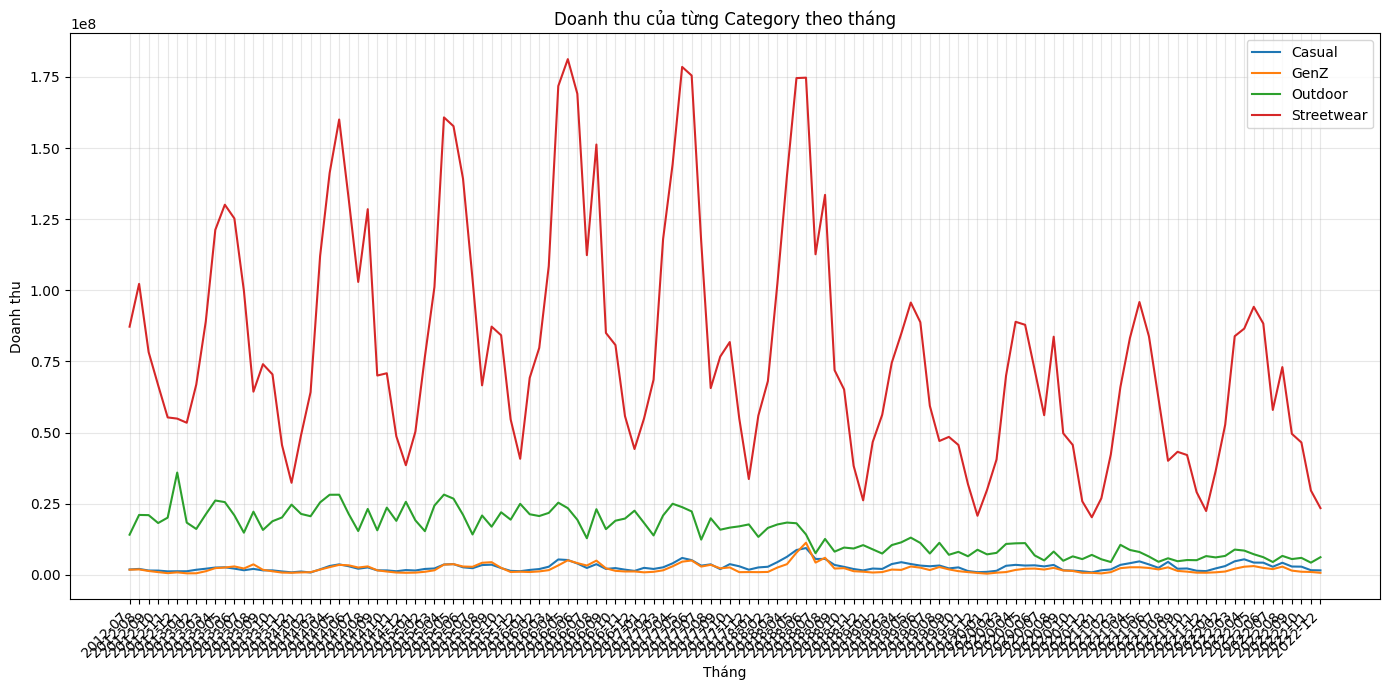

In [19]:
print("\n" + "=" * 100)
print("17. BIỂU ĐỒ THEO DÕI DOANH THU THEO THÁNG")
print("=" * 100)

plt.figure(figsize=(14, 7))

for category in monthly_pivot.columns:
    plt.plot(
        monthly_pivot.index.astype(str),
        monthly_pivot[category],
        label=category
    )

plt.title(
    'Doanh thu của từng Category theo tháng'
)

plt.xlabel('Tháng')
plt.ylabel('Doanh thu')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 18. Biểu đồ Coefficient of Variation (CV)

Biểu đồ cột hiển thị mức độ biến động (CV) của doanh thu cho mỗi Category, kèm theo các đường tham chiếu để đánh giá độ ổn định. Biểu đồ này giúp xác định nhanh chóng các Category có doanh thu biến động mạnh.


18. BIỂU ĐỒ COEFFICIENT OF VARIATION


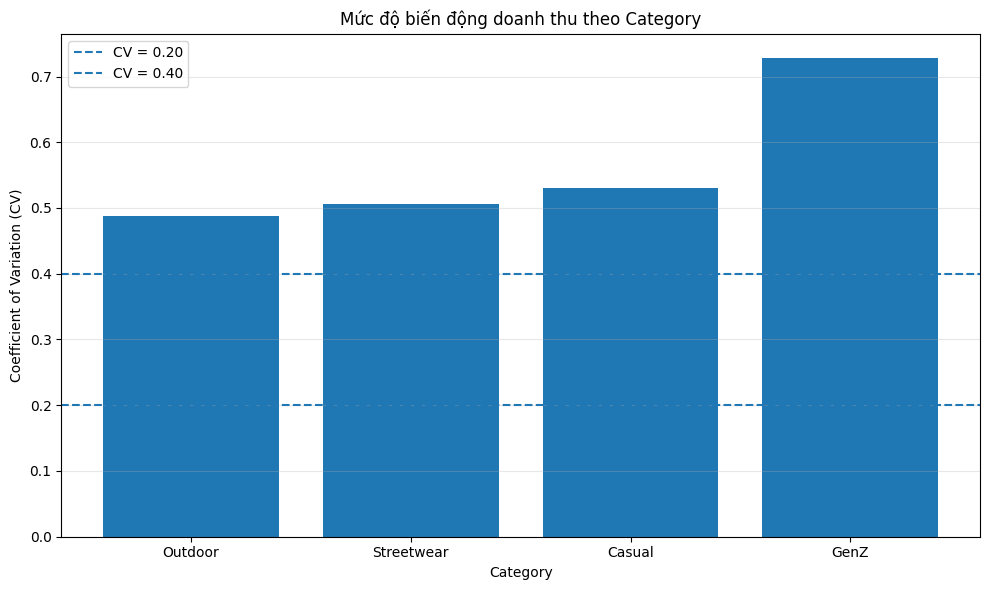

In [20]:
print("\n" + "=" * 100)
print("18. BIỂU ĐỒ COEFFICIENT OF VARIATION")
print("=" * 100)

plt.figure(figsize=(10, 6))

cv_sorted = result['CV'].sort_values()

plt.bar(
    cv_sorted.index,
    cv_sorted.values
)

plt.axhline(
    y=0.20,
    linestyle='--',
    label='CV = 0.20'
)

plt.axhline(
    y=0.40,
    linestyle='--',
    label='CV = 0.40'
)

plt.title(
    'Mức độ biến động doanh thu theo Category'
)

plt.xlabel('Category')
plt.ylabel('Coefficient of Variation (CV)')

plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 19. Tóm tắt kết quả

Tóm tắt các Measure, Metric và KPI chính được sử dụng trong toàn bộ phân tích, cung cấp một bản tổng hợp ngắn gọn về các yếu tố đã được xem xét.

In [21]:
print("\n" + "=" * 100)
print("19. TÓM TẮT")
print("=" * 100)

print("""
Measure:
- quantity
- unit_price
- discount_amount
- Revenue

Metric:
- Doanh thu theo tháng
- Doanh thu trung bình tháng
- Variance
- Standard Deviation
- Coefficient of Variation (CV)
- Tỷ lệ tăng trưởng doanh thu trung bình tháng

KPI:
- Tổng doanh thu của từng Category
- CV của từng Category
- Tỷ lệ tăng trưởng doanh thu trung bình tháng
- Phân loại ổn định / tăng trưởng / biến động mạnh / suy giảm
- Mức độ ưu tiên cải thiện chiến lược bán hàng
""")


19. TÓM TẮT

Measure:
- quantity
- unit_price
- discount_amount
- Revenue

Metric:
- Doanh thu theo tháng
- Doanh thu trung bình tháng
- Variance
- Standard Deviation
- Coefficient of Variation (CV)
- Tỷ lệ tăng trưởng doanh thu trung bình tháng

KPI:
- Tổng doanh thu của từng Category
- CV của từng Category
- Tỷ lệ tăng trưởng doanh thu trung bình tháng
- Phân loại ổn định / tăng trưởng / biến động mạnh / suy giảm
- Mức độ ưu tiên cải thiện chiến lược bán hàng

